In [35]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.tree import export_graphviz

import warnings
warnings.filterwarnings('ignore')

In [37]:
iris_data = load_iris(as_frame=False)
load_iris?
iris_data.data.shape

(150, 4)

Signature: load_iris(*, return_X_y=False, as_frame=False)
Docstring:
Load and return the iris dataset (classification).

The iris dataset is a classic and very easy multi-class classification
dataset.

=================   ==============
Classes                          3
Samples per class               50
Samples total                  150
Dimensionality                   4
Features            real, positive
=================   ==============

Read more in the :ref:`User Guide <iris_dataset>`.

Parameters
----------
return_X_y : bool, default=False
    If True, returns ``(data, target)`` instead of a Bunch object. See
    below for more information about the `data` and `target` object.

    .. versionadded:: 0.18

as_frame : bool, default=False
    If True, the data is a pandas DataFrame including columns with
    appropriate dtypes (numeric). The target is
    a pandas DataFrame or Series depending on the number of target columns.
    If `return_X_y` is True, then (`data`, `target`) w

In [39]:
sc = StandardScaler()
data = sc.fit_transform(iris_data.data)

In [45]:
x_train, x_test, y_train, y_test = train_test_split(data, iris_data.target, test_size=0.2, random_state=11)
dt_clf.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_split=16, random_state=156)

In [47]:
max_depths=[6,8,10,12,16,20,24]
for depth in max_depths:
    dt_clf = DecisionTreeClassifier(max_depth=depth,min_samples_split=16, random_state=156)
    dt_clf.fit(x_train, y_train)
    pred=dt_clf.predict(x_test)
    accuracy=accuracy_score(y_test, pred)
    print('max_depth = {0} 정확도 : {1:.4f}'.format(depth, accuracy))

max_depth = 6 정확도 : 0.9333
max_depth = 8 정확도 : 0.9333
max_depth = 10 정확도 : 0.9333
max_depth = 12 정확도 : 0.9333
max_depth = 16 정확도 : 0.9333
max_depth = 20 정확도 : 0.9333
max_depth = 24 정확도 : 0.9333


In [9]:
train_test_split?

Signature:
train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
)
Docstring:
Split arrays or matrices into random train and test subsets.

Quick utility that wraps input validation,
``next(ShuffleSplit().split(X, y))``, and application to input data
into a single call for splitting (and optionally subsampling) data into a
one-liner.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
*arrays : sequence of indexables with same length / shape[0]
    Allowed inputs are lists, numpy arrays, scipy-sparse
    matrices or pandas dataframes.

test_size : float or int, default=None
    If float, should be between 0.0 and 1.0 and represent the proportion
    of the dataset to include in the test split. If int, represents the
    absolute number of test samples. If None, the value is set to the
    complement of the train size. If ``train_size`` is also None, it will
    be set to 0.25.

trai

DecisionTreeClassifier(random_state=156)

In [13]:
export_graphviz(dt_clf, out_file="tree.dot", class_names=iris_data.target_names, feature_names=iris_data.feature_names, impurity=True, filled=True)

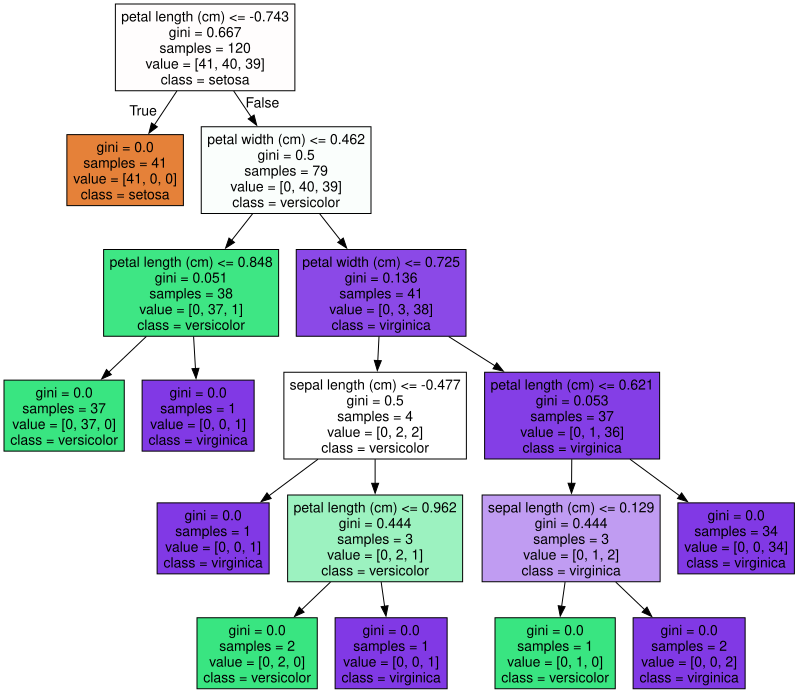

In [15]:
import graphviz
with open("tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

In [111]:
#pip install graphviz

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
